In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Advanced Gradient Descent Methods

Until now, we have referred to all three batch-size variants of Gradient Descent—Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent—simply as "Gradient Descent."

In a broader sense, however, these methods can be referred to as Vanilla Gradient Descent, as they all follow the basic gradient descent update rule:

$$
w_{t+1} = w_t - \eta \nabla L_{w_t}
$$

where $w_t$ is the current parameter value, $\eta$ is a constant learning rate, and $\nabla L_w$ is the derivative of the loss function with respect to the current $w_t$:

$$
\nabla L_{w} = \frac{\partial L}{\partial w}.
$$

Thus, vanilla gradient descent uses a constant learning rate $\eta \in \mathbb{R}$ and computes each parameter update solely from the gradient at the current parameter values, without explicitly incorporating information from previous gradients. It doesn't take into account past steps taken while traversing the loss space.

### **Momentum**

Using Vanilla GD can lead to two problems:

* The gradient of the loss function can be negligible or zero in regions such as saddle points, which leads to small or no weight updates according to the formula above. Consequently, the updates can become stagnant and the optimization process can progress very slowly or stop altogether.

* Learning is not accelerated when the gradient repeatedly points in the same direction as previous gradients. Instead, the magnitude of each update remains determined by the current gradient and the constant learning rate. GD could converge faster if information from previous gradients were used to accelerate the descent when they consistently point in the same direction.

Momentum, an extension to Vanilla Gradient Descent, addresses these limitations.

As the name suggests, we incorporate momentum into gradient descent based on past gradients. Essentially, we remember previous gradients and let the current parameter update be influenced by both the accumulated past gradients and the newly computed gradient at point $t$.

Momentum is expressed as

$$
w_{t+1} = w_t - \eta v_t
$$

where

$$
v_t =
\begin{cases}
(1 - \beta) \nabla L_{w_t}, & \text{if } t=1 \\
\beta v_{t-1} + (1-\beta)\nabla L_{w_t}, & \text{if } t>1.
\end{cases}
$$

Here, $v_{t-1}$ is the accumulated weighted gradient up to iteration $t-1$ and $\beta$ is a hyperparameter controlling the influence of past gradients. 

Usually, $\beta$ is set to $0.9$, meaning that $90\%$ of the previous velocity is retained while $10\%$ of the newly computed gradient is incorporated.

Since $v_t$ recursively contains previous values of $v$, it effectively represents an exponentially weighted combination of past gradients. Thus, gradients from more distant iterations continue to influence the current update, but their influence decreases over time.

Let's explore why that is:

For $t=1$, we get
$$
v_1 = (1-\beta) \nabla L_{w_1}
$$

For $t=2$, we get
$$
v_2 = \beta v_{2-1} + (1 - \beta) \nabla L_{w_2} = \beta (1 - \beta) \nabla L_{w_1} + (1 - \beta) \nabla L_{w_2}
$$

For $t=3$, we get
$$
v_3 = \beta v_{3-1} + (1 - \beta) \nabla L_{w_3} = \beta (\beta (1 - \beta) \nabla L_{w_1} + (1 - \beta) \nabla L_{w_2}) + (1 - \beta) \nabla L_{w_3} = \beta^2 (1 - \beta) \nabla L_{w_1} + \beta (1-\beta) \nabla L_{w_2} + (1 - \beta) \nabla L_{w_3}
$$

If we use $\beta = 0.9$, we have
$$
\beta^2 (1 - \beta) \nabla L_{w_1} + \beta (1-\beta) \nabla L_{w_2} + (1 - \beta) \nabla L_{w_3} = 0.9^2 - 0.9^3 \nabla L_{w_1} + 0.9-0.9^2 \nabla L_{w_2} + 1 - 0.9 \nabla L_{w_3} = 0.081 \nabla L_{w_1} + 0.09 \nabla L_{w_2} + 0.1 \nabla L_{w_3}
$$

And the real influence of past gradients becomes obvious.

Hence, for any point $n \leq t$, the influence of a particular past gradient can be calculated as $\beta^{t-n} - \beta^{t-n+1}$.

In general, this translates to
$$
v_t = (1-\beta)\nabla L_{w_t} + \beta(1-\beta) \nabla L_{w_{t-1}} + \beta^2(1-\beta) \nabla L_{w_{t-2}} + \dots + \beta^{t-1} (1-\beta) \nabla L_{w_1}
$$

and thats why its called an exponentially weighted combination of past gradients.

To conclude, Momentum remembers past gradients and uses an exponentially weighted combination of past and current gradients for the parameter update. 

This allows the optimization process to build up velocity in directions where gradients consistently point in the same direction, potentially accelerating convergence and reducing oscillations.


### **AdaGrad**

Momentum is considered a non-adaptive optimizer, as it does not adapt its constant learning rate to the individual parameters or gradients.

AdaGrad, however, adjusts its learning rate individually for each parameter and uses accumulated past gradients to scale updates, similarly to Momentum.

AdaGrad takes past gradients into account and assigns smaller learning rates to parameters with consistently large gradients, whereas parameters with smaller accumulated gradients are assigned larger learning rates.

With this, the need to manually find and tune a suitable learning rate $\eta$ for each parameter is reduced.

AdaGrad is expressed as

$$
w_{t+1} = w_t - \eta_{w_t} \nabla L_{w_t}
$$

where

$$
\eta_{w_t} = \frac{\eta}{\sqrt{G_{w_t}} + \epsilon}
$$

with

$$
G_{w_t} = \sum_{i=1}^t \nabla L_{w_i}^2
$$

Hence, we compute an adaptive learning rate for each parameter $w$ by dividing the initial learning rate $\eta$ by the square root of the sum of all past squared gradients $\nabla L_{w_i}^2$, plus a small $\epsilon = 10^{-8}$ to avoid division by zero.

And since we divide by $G_{w_t}$, the bigger the sum of the past squared gradients, the smaller the new learning rate $\eta_{w_t}$.


### **RMSProp**

While there are already many benefits of using AdaGrad over Momentum or Vanilla GD, it does not perform as well when learning rates need to remain sufficiently large and has the problem of a rapidly decreasing effective learning rate, as the learning rate is scaled by the accumulated sum of past squared gradients.

RMSProp, short for Root Mean Square Propagation, improves upon AdaGrad by using an exponentially weighted moving combination of past squared gradients instead of the sum of all past squared gradients.

This change in the denominator prevents the adaptive learning rate from shrinking too quickly.

$$
w_{t+1} = w_t - \eta_{w_t} \nabla L_{w_t}
$$

where

$$
\eta_{w_t} = \frac{\eta}{\sqrt{v_t} + \epsilon}
$$

with

$$
v_t = \beta v_{t-1} + (1-\beta) \nabla L_{w_t}^2
$$

and

$$
v_t =
\begin{cases}
(1 - \beta) \nabla L_{w_t}^2, & \text{if } t=1 \\
\beta v_{t-1} + (1-\beta)\nabla L_{w_t}^2, & \text{if } t>1.
\end{cases}
$$


The only difference to Momentum is the use of squared gradients $\nabla L_{w_t}^2$ in the exponentially weighted moving combination, for two main reasons:

* The square measures the magnitude rather than the direction of the gradient. It removes the sign of negative gradients and therefore captures the size of the gradient without allowing positive and negative gradients to cancel each other out.

* The square root in the denominator brings the accumulated squared gradients back to the same scale as the current gradient $\nabla L_{w_t}$.

To sum up, RMSProp assigns more weight to recent gradients, as demonstrated for Momentum, while using their squared magnitudes. Consequently, parameters with large recent gradients receive smaller effective learning rates, whereas parameters with smaller recent gradients receive larger effective learning rates. This allows RMSProp to avoid the continually shrinking learning rates of AdaGrad.

### **Adam**

While RMSProp maintains an exponentially weighted moving average of the squared past gradients to scale the learning rate, it only considers the magnitude of these gradients rather than their direction due to the squaring operation.

Momentum, however, remembers the direction and influence of past gradients to accelerate updates in directions with a consistent gradient.

Adam efficiently combines RMSProp and Momentum to combine both advantages: using the magnitude of past gradients through an exponentially weighted moving average to adapt the learning rate, while also accelerating gradient descent by keeping track of the direction of past gradients using the same mechanism.

$$
w_{t+1} = w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

where

$$
\hat{m}_t =
\frac{m_t}{1-\beta_1^t}
=
\frac{\beta_1m_{t-1}+(1-\beta_1)\nabla L_{w_t}}
{1-\beta_1^t}
$$

and

$$
\hat{v}_t =
\frac{v_t}{1-\beta_2^t}
=
\frac{\beta_2v_{t-1}+(1-\beta_2)\nabla L_{w_t}^2}
{1-\beta_2^t}
$$

with

$$
m_t =
\begin{cases}
(1-\beta_1)\nabla L_{w_t}, & \text{if } t=1 \\\\
\beta_1m_{t-1}+(1-\beta_1)\nabla L_{w_t}, & \text{if } t>1.
\end{cases}
$$

and

$$
v_t =
\begin{cases}
(1-\beta_2)\nabla L_{w_t}^2, & \text{if } t=1 \\\\
\beta_2v_{t-1}+(1-\beta_2)\nabla L_{w_t}^2, & \text{if } t>1.
\end{cases}
$$

Here, $m_t$ denotes the first moment of the gradient and tracks its past direction and influence, whereas $v_t$ denotes the second moment and tracks the magnitude of past gradients. Both contribute to the final parameter update, with $v_t$ determining the adaptive scaling and $m_t$ determining the direction of the update.

We use bias correction,

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}
$$

and

$$
\hat{v}_t = \frac{v_t}{1-\beta_2^t},
$$

as both $m_t$ and $v_t$ are initialized to zero. This is particularly important during the initial training steps, as the exponentially weighted averages are initially biased towards zero due to their initialization.

For instance, for $m_1$ and a typical parameter value of $\beta_1=0.9$:

$$
m_1=(1-\beta_1)\nabla L_{w_1}
=0.1\nabla L_{w_1}
$$

and subsequently

$$
\hat{m}_1
=
\frac{m_1}{1-\beta_1^1}
=
\frac{0.1\nabla L_{w_1}}{1-0.9^1}
=
\frac{0.1\nabla L_{w_1}}{0.1}
=
\nabla L_{w_1}.
$$

Thus, the bias correction compensates for the initial influence of the zero initialization and recovers the full first gradient at $t=1$.


We typically set $\beta_1 = 0.9$ and $\beta_2 = 0.999$ for Adam.


### **AdamW**

While Adam is already a commonly used Gradient Descent optimizer, it can still benefit from regularization to reduce overfitting.

There is no mechanism in Adam that directly controls the magnitude of the parameters $w$. Hence, large parameter values can contribute to overfitting the training data.

Therefore, AdamW introduces decoupled weight decay, a regularization method related to $L2$ regularization that penalizes large parameter values and can improve the generalization of the model.

AdamW uses the same gradient-based update as Adam, but applies weight decay separately from the gradient update:

$$
w_{t+1} = w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon} - \eta\lambda w_t
$$

or equivalently,

$$
w_{t+1} = w_t - \eta (\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon} + \lambda w_t)
$$

Here, $\eta\lambda w_t$ is the weight decay term, which continuously shrinks the parameters towards zero and therefore discourages very large parameter values.

The weight decay is called decoupled because it is not incorporated into the gradient used by Adam to calculate the first and second moments.

$\lambda w_t$ is then applied separately during the parameter update. This is different from simply adding an $L2$ penalty to the loss, where $\lambda w_t$ would become part of the gradient and would consequently also be scaled by Adam's adaptive update mechanism.

Thus, AdamW separates the two objectives: Adam adapts the parameter update based on the gradient, while weight decay independently controls the magnitude of the parameters.

Typical AdamW hyperparameters are $\beta_1=0.9$, $\beta_2=0.999$ and $\lambda = 0.01$. 


In [1]:
%run src/gradient_descent_optimizers.py

### Understanding Momentum in Non-Convex Optimization

Consider the loss function $f(x)$ associated with an optimization problem.

When Vanilla Gradient Descent is initialized to the right of the local minimum $x \approx 3$, the update rule depends exclusively on the immediate local gradient. Consequently, the algorithm becomes trapped in this suboptimal local minimum.

By contrast, Momentum-based optimization incorporates a moving combination of historical gradients into the update step. 

By leveraging the accumulated velocity from previous iterations where gradients consistently pointed in the direction of descent the algorithm generates sufficient momentum to traverse the local minimum and converge toward the global minimum at $x \approx −3.2$.

In [237]:
def f(x):
    """f(x) = 0.1x^4 - 2x^2 + x + 5"""
    return (0.1 * x**4) - (2 * x **2) + x + 5

def df(x):
    """df(X) = 0.4x^3 - 4x + 1"""
    return (0.4 * x**3) - (4 * x) + 1

epochs = 100
start_x = 6
learning_rate = 0.03
beta = 0.9
v_t = 0

x_vanilla_hist = [start_x]
for _ in range(epochs):
    x_vanilla_hist.append(x_vanilla_hist[-1] - learning_rate * df(x_vanilla_hist[-1]))

x_momentum_hist = [start_x]
for _ in range(epochs):
    v_t = beta * v_t + (1-beta) * df(x_momentum_hist[-1])
    x_momentum_hist.append(x_momentum_hist[-1] - learning_rate * v_t)

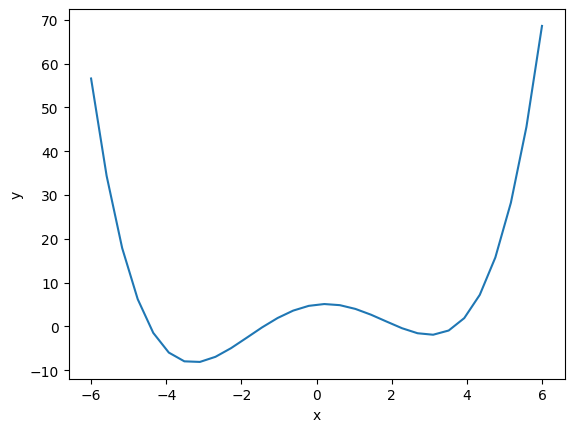

In [291]:
x_values = np.linspace(-6, 6, 30)
y_values = f(x_values)

plt.plot(x_values, y_values)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

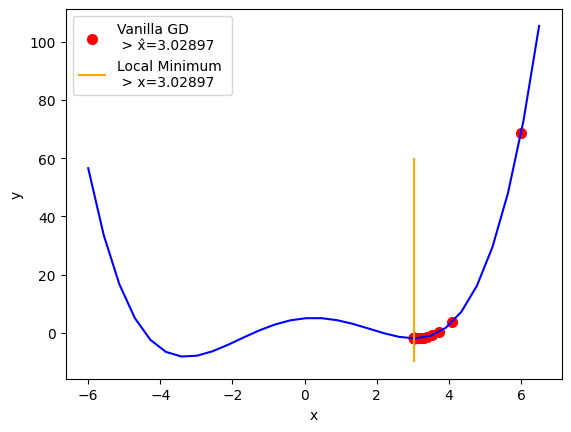

In [292]:
x_values = np.linspace(-6, 6.5, 30)
y_values = f(x_values)

local_min = 3.0289661389121214
plt.plot(x_values, y_values, color="blue")
plt.scatter(x_vanilla_hist, f(np.array([x_vanilla_hist])[0]), color="red", linewidth=2, label=f"Vanilla GD \n > x̂={x_vanilla_hist[-1]:.5f}")
plt.vlines(local_min, ymin=-10, ymax=60, color="orange", label=f"Local Minimum \n > x={local_min:.5f}")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Zooming in reveals that Vanilla GD converges to the local minimum but never takes a step further.

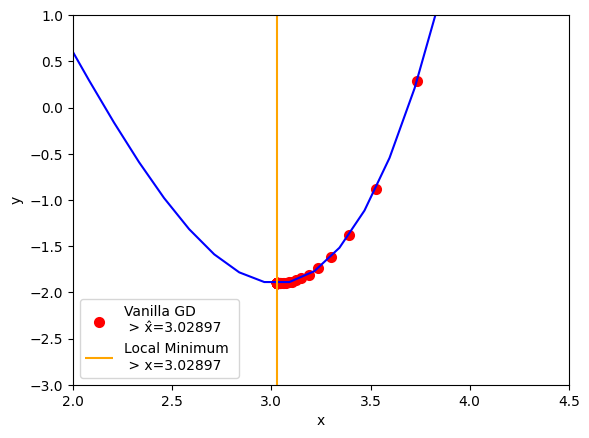

In [293]:
x_values = np.linspace(-6, 6.5, 100)
y_values = f(x_values)

local_min = 3.0289661389121214
plt.plot(x_values, y_values, color="blue")
plt.scatter(x_vanilla_hist, f(np.array([x_vanilla_hist])[0]), color="red", linewidth=2, label=f"Vanilla GD \n > x̂={x_vanilla_hist[-1]:.5f}")
plt.vlines(local_min, ymin=-10, ymax=60, color="orange", label=f"Local Minimum \n > x={local_min:.5f}")
plt.xlim(2, 4.5)
plt.ylim(-3, 1)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

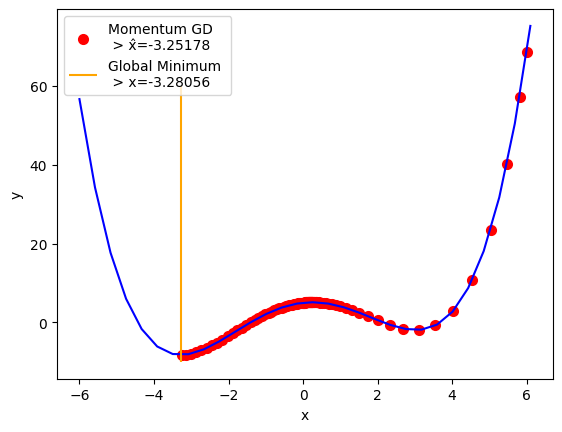

In [294]:
x_values = np.linspace(-6, 6.1, 30)
y_values = f(x_values)

global_min = -3.2805586898624495
plt.plot(x_values, y_values, color="blue")
plt.scatter(x_momentum_hist, f(np.array([x_momentum_hist])[0]), color="red", linewidth=2, label=f"Momentum GD \n > x̂={x_momentum_hist[-1]:.5f}")
plt.vlines(global_min, ymin=-10, ymax=60, color="orange", label=f"Global Minimum \n > x={global_min:.5f}")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

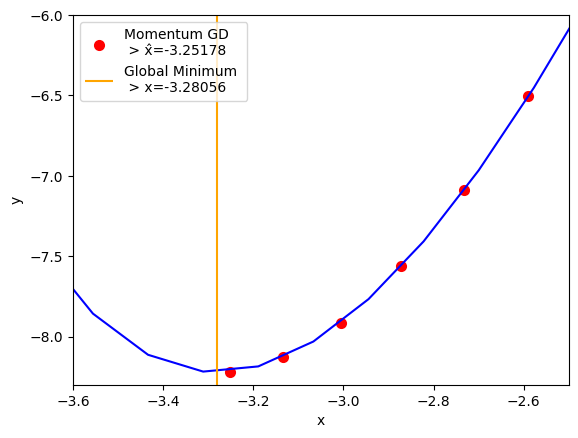

In [295]:
x_values = np.linspace(-6, 6.1, 100)
y_values = f(x_values)

global_min = -3.2805586898624495
plt.plot(x_values, y_values, color="blue")
plt.scatter(x_momentum_hist, f(np.array([x_momentum_hist])[0]), color="red", linewidth=2, label=f"Momentum GD \n > x̂={x_momentum_hist[-1]:.5f}")
plt.vlines(global_min, ymin=-10, ymax=60, color="orange", label=f"Global Minimum \n > x={global_min:.5f}")
plt.xlim(-3.6, -2.5)
plt.ylim(-8.3, -6)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Empirical Evaluation On More Complex Data

To evaluate these methods in a more complex, non-convex optimization setting, we return to the Titanic dataset.

We perform a comparative analysis of all six optimizer variants, evaluating their optimization performance using binary cross-entropy (log-loss).

To ensure a controlled experiment, each optimizer is trained under uniform hyperparameters: $100$ epochs with a mini-batch size of $32$, while retaining the previously defined values for $\beta$ and the weight decay $\lambda$.

In [385]:
data = pd.read_csv("../2_machine_learning/data/titanic_dataset.csv")

data["Sex"] = data["Sex"].apply(lambda x: 1 if x == "male" else 0)
data = data.drop(columns=["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"])
data = data[~data["Age"].isna()]

X = data.drop(columns=["Survived"])
y = data["Survived"]

print(f"n_samples: {X.shape[0]} | m_features: {X.shape[1]}")

n_samples: 714 | m_features: 4


In [386]:
lr_vanilla = LogisticRegression()
lr_vanilla.fit(X, y, optimizer="vanilla", epochs=100, batch_size=32)

lr_momentum = LogisticRegression()
lr_momentum.fit(X, y, optimizer="momentum", epochs=100, batch_size=32)

lr_adagrad = LogisticRegression()
lr_adagrad.fit(X, y, optimizer="adagrad", epochs=100, batch_size=32)

lr_rmsprop = LogisticRegression()
lr_rmsprop.fit(X, y, optimizer="rmsprop", epochs=100, batch_size=32)

lr_adam = LogisticRegression()
lr_adam.fit(X, y, optimizer="adam", epochs=100, batch_size=32)

lr_adamw = LogisticRegression()
lr_adamw.fit(X, y, optimizer="adamw", epochs=100, batch_size=32)

The plot reveals several key characteristics regarding the optimization dynamics of the six variants:

- Vanilla GD exhibits extreme loss spikes and heavy oscillation, demonstrating severe sensitivity to the gradient noise inherent in mini-batch training.
- Momentum displays moderate stability with minor oscillations. However, it ultimately converges to a similar final loss as Vanilla GD.
- AdaGrad achieves smooth early progress but flattens out after approximately 10 epochs, as the sum of squared historical gradients rapidly decays the effective learning rate toward zero.
- RMSProp, Adam and AdamW prove to be the superior optimization methods, all converging smoothly to the lowest overall log-loss.

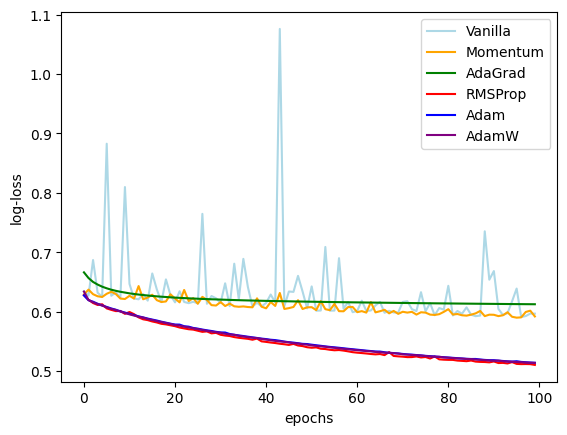

In [389]:
plt.plot(lr_vanilla.losses_, color="lightblue", label="Vanilla")
plt.plot(lr_momentum.losses_, color="orange", label="Momentum")
plt.plot(lr_adagrad.losses_, color="green", label="AdaGrad")
plt.plot(lr_rmsprop.losses_, color="red", label="RMSProp")
plt.plot(lr_adam.losses_, color="blue", label="Adam")
plt.plot(lr_adamw.losses_, color="purple", label="AdamW")

plt.xlabel("epochs")
plt.ylabel("log-loss")
plt.legend()
plt.show()

As AdamW simply modifies Adam by adding decoupled weight decay, it can be safely excluded from this comparison because the parameter values $w$ remain naturally centered around zero, both optimizers exhibit virtually identical performance.

This zoomed-in plot highlights the high similarity between RMSProp and Adam, demonstrating that for this specific problem, the momentum term does not contribute significantly to the final update step (as observed previously).

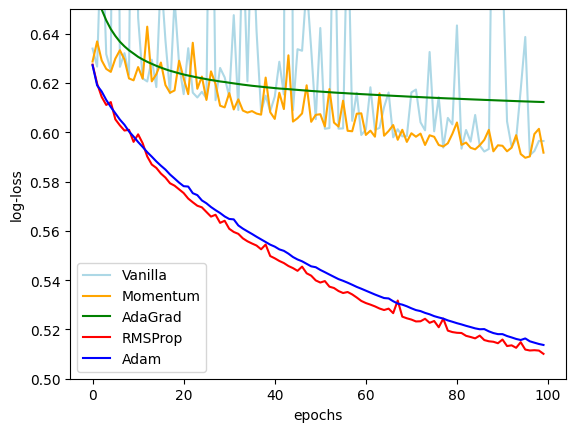

In [390]:
plt.plot(lr_vanilla.losses_, color="lightblue", label="Vanilla")
plt.plot(lr_momentum.losses_, color="orange", label="Momentum")
plt.plot(lr_adagrad.losses_, color="green", label="AdaGrad")
plt.plot(lr_rmsprop.losses_, color="red", label="RMSProp")
plt.plot(lr_adam.losses_, color="blue", label="Adam")

plt.legend()
plt.xlabel("epochs")
plt.ylabel("log-loss")
plt.ylim(0.5, 0.65)
plt.show()